In [27]:
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
protein = "VCAM1"

In [4]:
vgat_geph_results_file = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}-LacZ_VGAT-GEPH_output_data/metric_results.csv"
vgat_geph_results = pd.read_csv(vgat_geph_results_file)
vgat_geph_results.head(2)

,Unnamed: 0,img_filename,local_peak_colocalized_spots,local_peak_colocalized_spots_rot,overlap_coeff,overlap_coeff_rot,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,...,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain
0,0,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_LacZ-...,48,10,0.155255,0.032665,6.883428,1.448246,0.255541,0.0,...,199.862944,16.532498,8.652007,61.032492,25.066581,0.203442,0.159660,LacZ-gRNA,CA3 SO,Brain-4-2
1,1,CRISPR-Exp4_IHC-Exp7_Brain-4-2_section-1_VCAM1...,16,7,0.148589,0.043393,12.059629,3.521793,0.166916,0.0,...,256.204743,62.603057,24.357880,121.853710,48.500905,0.107266,0.109731,VCAM1-gRNA,CA1 SLM,Brain-4-2


In [5]:
vgat_geph_results["target"] = vgat_geph_results["gRNA"].str.cat(vgat_geph_results[["Brain"]], sep = "_")

In [6]:
df2_grouped_brain = vgat_geph_results.groupby(["target", "hippocampal_layer"], as_index=False)[["local_peak_colocalized_spots",
                                                "overlap_coeff",
                                                "overlap_um2",
                                                "pearson_cor",
                                                "presynapse_image_mfi",
                                                "postsynapse_image_mfi",
                                                "pre_puncta_density_per_100_um2",
                                                "post_puncta_density_per_100_um2",
                                                "pre_staining_area_um2",
                                                "post_staining_area_um2",
                                                "pre_mean_puncta_size_um2",
                                                "post_mean_puncta_size_um2"]].mean()

In [10]:
# to long format
df_melted = df2_grouped_brain.melt(id_vars=['target', 'hippocampal_layer'], var_name='metric', value_name='value')

# create new column based on hippocampal layer and metric
df_melted['hippocampal_layer_metric'] = df_melted['hippocampal_layer'] + '_' + df_melted['metric']

# pivot the dataframe back
df_pivot = df_melted.pivot(index='target', columns='hippocampal_layer_metric', values='value')


In [17]:
df_pivot.head(5)

hippocampal_layer_metric,CA1 SLM_local_peak_colocalized_spots,CA1 SLM_overlap_coeff,CA1 SLM_overlap_um2,CA1 SLM_pearson_cor,CA1 SLM_post_mean_puncta_size_um2,CA1 SLM_post_puncta_density_per_100_um2,CA1 SLM_post_staining_area_um2,CA1 SLM_postsynapse_image_mfi,CA1 SLM_pre_mean_puncta_size_um2,CA1 SLM_pre_puncta_density_per_100_um2,...,DG ML_overlap_um2,DG ML_pearson_cor,DG ML_post_mean_puncta_size_um2,DG ML_post_puncta_density_per_100_um2,DG ML_post_staining_area_um2,DG ML_postsynapse_image_mfi,DG ML_pre_mean_puncta_size_um2,DG ML_pre_puncta_density_per_100_um2,DG ML_pre_staining_area_um2,DG ML_presynapse_image_mfi
target,,,,,,,,,,,,,,,,,,,,,
LacZ-gRNA_Brain-4,27.666667,0.199567,13.225041,0.262538,0.110781,23.016910,46.266630,236.547826,0.116441,40.541358,...,6.919776,0.213531,0.109615,8.615268,17.151775,148.069555,0.104199,56.137014,106.009899,223.099682
LacZ-gRNA_Brain-4-2,31.666667,0.176516,14.979974,0.224199,0.105471,25.184505,48.215799,255.884256,0.111254,66.129990,...,5.714040,0.156771,0.105159,8.835701,16.874053,142.818637,0.102346,69.509967,129.255098,232.386719
LacZ-gRNA_Brain-5,31.666667,0.187125,15.772818,0.240997,0.110580,24.835485,49.804894,251.617380,0.110698,63.815440,...,9.978131,0.198388,0.108325,13.868928,27.282682,177.989779,0.103411,76.196444,142.973111,244.970842
LacZ-gRNA_Brain-7,21.500000,0.165961,15.647020,0.195657,0.108314,26.562213,52.206710,238.478268,0.109134,75.884164,...,8.503759,0.218601,0.106124,10.994111,21.191246,154.907051,0.102993,71.282618,133.552981,262.514879
VCAM1-gRNA_Brain-4,24.666667,0.201412,12.311226,0.261285,0.109988,22.814847,45.551026,224.377269,0.117409,34.681506,...,6.527330,0.217473,0.109125,10.378735,20.434466,163.396543,0.106614,37.087903,72.179442,221.825783


In [18]:
z_scores = df_pivot.apply(zscore)
z_scores

hippocampal_layer_metric,CA1 SLM_local_peak_colocalized_spots,CA1 SLM_overlap_coeff,CA1 SLM_overlap_um2,CA1 SLM_pearson_cor,CA1 SLM_post_mean_puncta_size_um2,CA1 SLM_post_puncta_density_per_100_um2,CA1 SLM_post_staining_area_um2,CA1 SLM_postsynapse_image_mfi,CA1 SLM_pre_mean_puncta_size_um2,CA1 SLM_pre_puncta_density_per_100_um2,...,DG ML_overlap_um2,DG ML_pearson_cor,DG ML_post_mean_puncta_size_um2,DG ML_post_puncta_density_per_100_um2,DG ML_post_staining_area_um2,DG ML_postsynapse_image_mfi,DG ML_pre_mean_puncta_size_um2,DG ML_pre_puncta_density_per_100_um2,DG ML_pre_staining_area_um2,DG ML_presynapse_image_mfi
target,,,,,,,,,,,,,,,,,,,,,
LacZ-gRNA_Brain-4,0.523665,1.365091,-0.878344,1.349047,1.339880,-1.053086,-0.766001,-0.184307,1.331387,-1.395162,...,-0.724680,0.699813,1.033998,-1.437524,-1.324788,-1.133670,-0.191558,-0.677125,-0.716092,-0.781197
LacZ-gRNA_Brain-4-2,1.136736,-0.243556,0.408180,-0.017413,-1.423328,0.388702,-0.028797,1.295003,-0.479590,0.439590,...,-1.600473,-2.382315,-1.890444,-1.305212,-1.408134,-1.611333,-1.363505,0.353875,0.265011,-0.115353
LacZ-gRNA_Brain-5,1.136736,0.496807,0.989405,0.581284,1.235379,0.156550,0.572222,0.968571,-0.673924,0.273632,...,1.496774,-0.122449,0.187374,1.715933,1.715546,1.588104,-0.690137,0.869376,0.844003,0.786879
LacZ-gRNA_Brain-7,-0.421487,-0.980114,0.897183,-1.034704,0.055972,1.305093,1.480625,-0.036621,-1.219992,1.138982,...,0.425856,0.975164,-1.256936,-0.009648,-0.112523,-0.511678,-0.954066,0.490540,0.446411,2.044718
VCAM1-gRNA_Brain-4,0.063862,1.493874,-1.548252,1.304389,0.927286,-1.187490,-1.036653,-1.115401,1.669063,-1.815324,...,-1.009735,0.913909,0.711848,-0.379021,-0.339636,0.260591,1.335767,-2.145735,-2.143963,-0.872531
VCAM1-gRNA_Brain-4-2,-0.957924,-0.955562,-1.233907,-0.688460,-0.349971,-1.407424,-1.657220,0.515145,-0.407114,-0.029306,...,-0.167769,-0.097814,-0.110479,-0.048239,-0.051420,0.541105,0.657812,-0.334403,-0.297657,-0.440294
VCAM1-gRNA_Brain-5,0.472576,0.130368,1.144287,0.113051,-0.700613,0.950755,0.860918,0.461976,0.624651,0.355294,...,1.102812,0.116405,1.078136,0.547169,0.634607,0.980280,-0.338909,1.297071,1.319081,-1.155985
VCAM1-gRNA_Brain-7,-1.954165,-1.306909,0.221446,-1.607195,-1.084605,0.846898,0.574907,-1.904366,-0.844480,1.032295,...,0.477216,-0.102712,0.246503,0.916542,0.886349,-0.113398,1.544597,0.146401,0.283205,0.533763


<Axes: xlabel='hippocampal_layer_metric', ylabel='target'>

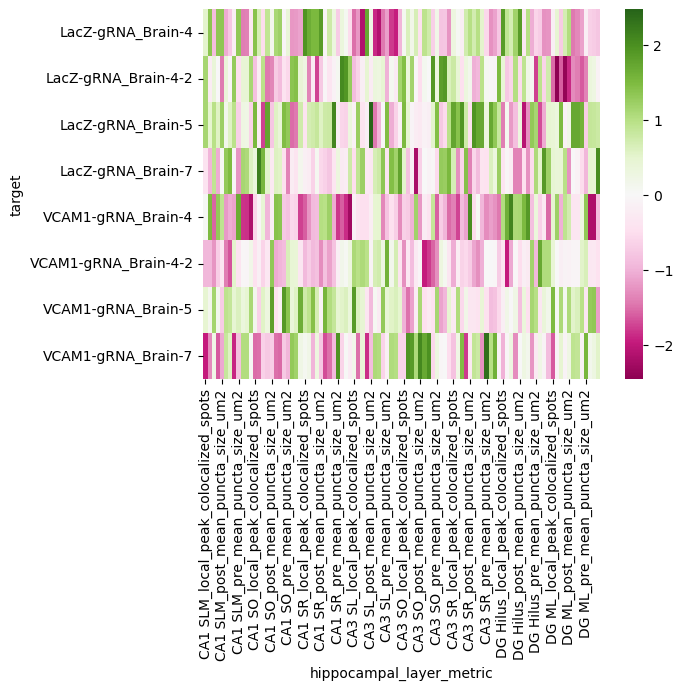

In [14]:
sns.heatmap(z_scores, cmap="PiYG")

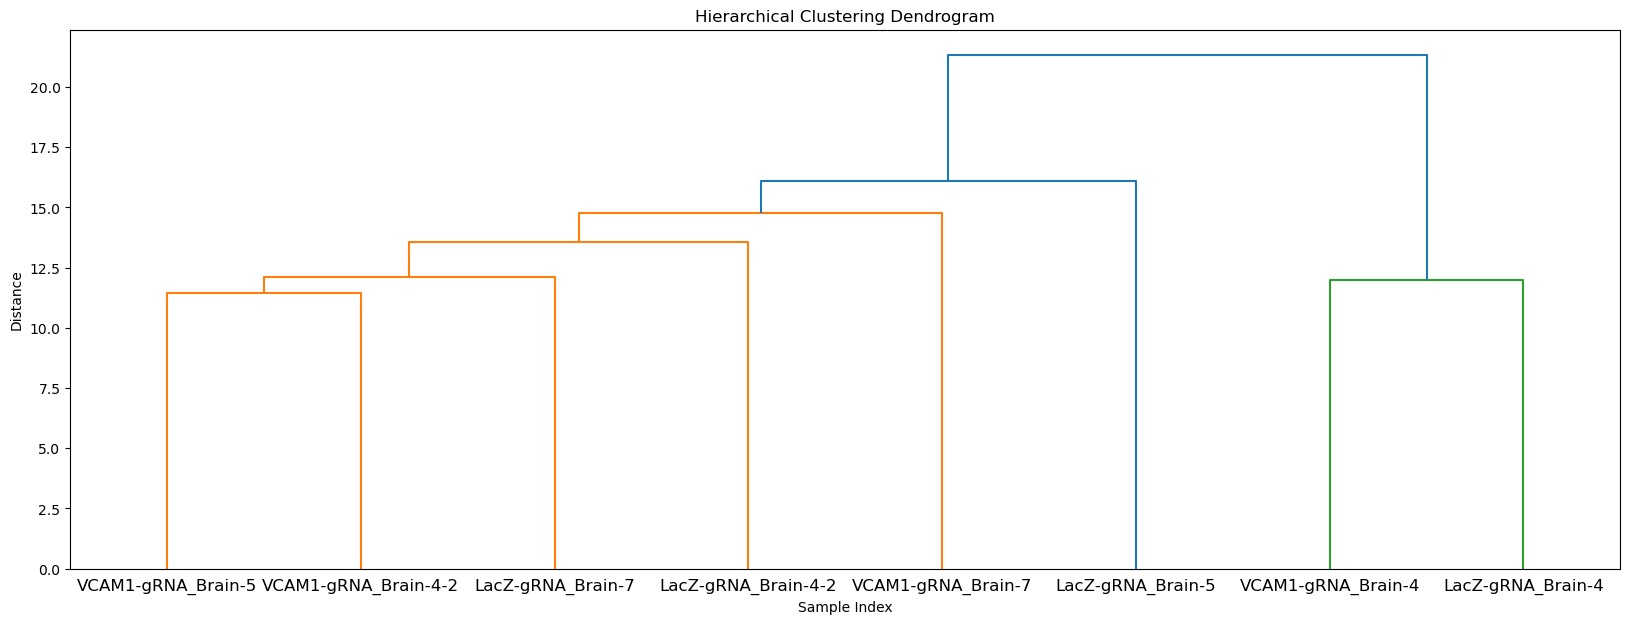

In [31]:
linked = linkage(z_scores, method='ward')


# Create a dendrogram
plt.figure(figsize=(20, 7))
dendrogram(linked, orientation='top', labels=df_pivot.index, distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()


KeyError: -1

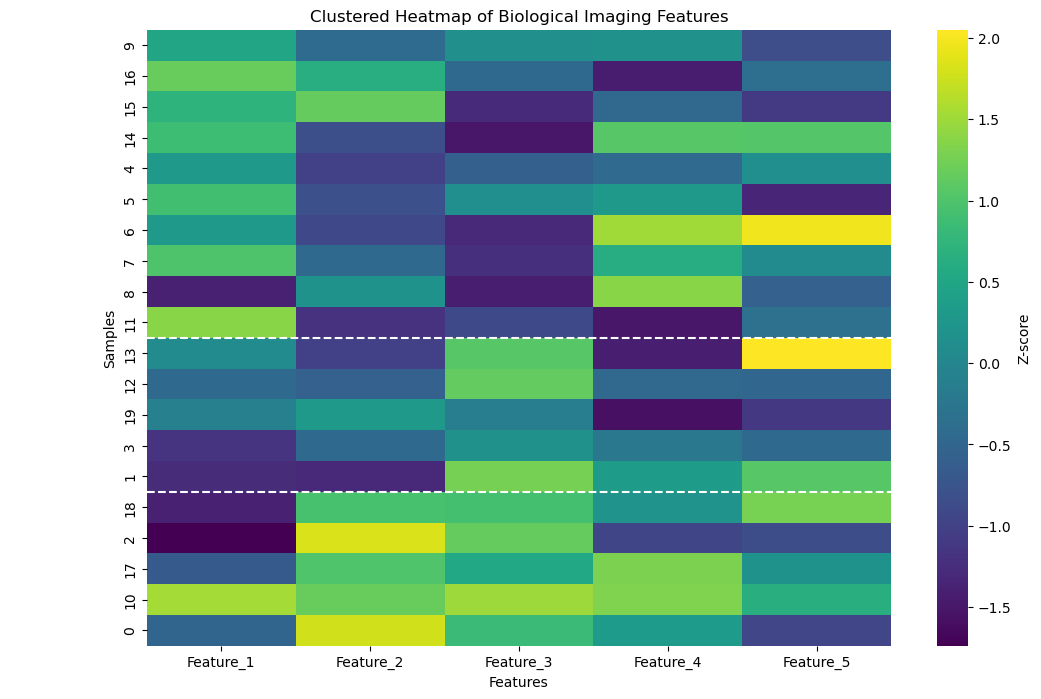

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt



# Step 2: Standardize the features (calculate z-scores)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Step 3: Perform clustering
# You can adjust the number of clusters (n_clusters) as needed
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled['Cluster'] = kmeans.fit_predict(df_scaled)

# Step 4: Sort the DataFrame by cluster for better visualization
df_sorted = df_scaled.sort_values('Cluster')

# Step 5: Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_sorted.drop('Cluster', axis=1), 
            cmap='viridis', 
            cbar_kws={'label': 'Z-score'})

# Add cluster separators
cluster_sizes = df_sorted['Cluster'].value_counts().sort_index()
separators = np.cumsum(cluster_sizes)[:-1]
for separator in separators:
    plt.axhline(y=separator, color='white', linestyle='--')

plt.title('Clustered Heatmap of Biological Imaging Features')
plt.xlabel('Features')
plt.ylabel('Samples')

# Add cluster labels
for i, separator in enumerate(separators):
    plt.text(-0.5, (separator + separators[i-1 if i > 0 else 0]) / 2, f'Cluster {i}', 
             va='center', ha='right', rotation=0, color='white')
plt.text(-0.5, (df_sorted.shape[0] + separators[-1]) / 2, f'Cluster {len(separators)}', 
         va='center', ha='right', rotation=0, color='white')

plt.tight_layout()
plt.show()

# Optional: Print cluster assignments
print(df_sorted['Cluster'].value_counts().sort_index())
